# Credit-card default: XGBoost and decision costs
**SC6122 · Group 5 · Part 4**

We examine two separate questions: does hyperparameter tuning improve the ranking of default risk, and does a validation-selected threshold reduce a specified decision loss?

This notebook reads the completed, frozen experiment. It does not reselect a model or threshold from test outcomes. The shared split, source data and teammates' notebooks are unchanged. See `README_PART4.md` for environment setup and `part4/experiment.py` for the complete training procedure.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image
from part4.evaluation import metrics, select_threshold
from part4.experiment import file_hash

ROOT = Path.cwd()
OUT = ROOT / "results" / "xgboost"

def read_result(name):
    return pd.read_csv(OUT / name, float_precision="round_trip")

protocol = json.loads((OUT / "protocol_frozen.json").read_text())
metadata = json.loads((OUT / "run_metadata.json").read_text())
assert file_hash(OUT / "protocol_frozen.json") == metadata["Frozen_protocol_SHA256"]
assert file_hash(OUT / "test_predictions.csv") == metadata["Test_predictions_SHA256"]
for name, expected in protocol["Model_SHA256"].items():
    assert file_hash(OUT / name) == expected
print("Frozen protocol, model files and test prediction hashes verified.")

Frozen protocol, model files and test prediction hashes verified.


## 1. Experimental design
The existing 24,000 training observations are split into **18,000 fitting** and **6,000 validation** rows (stratified, seed 42). The existing **6,000 test rows** remain held out.

- `row_id` and the label are excluded from predictors. SEX, EDUCATION and MARRIAGE are one-hot encoded within every fitting fold; the remaining predictors follow the group's cleaning.
- Five-fold stratified CV compares 24 configurations, including a baseline, using mean average precision (AP). AP is not trapezoidal PR-AUC.
- Baseline and selected models are both fitted to 18,000 rows. Validation predictions determine decision thresholds; there is no refit after threshold selection.
- Model files and a protocol containing parameters and thresholds were frozen before the runner read test observations.

To reproduce independently, run `python -m part4.experiment --output-dir results/xgboost_reproduction`, then `python -m part4.plots --output-dir results/xgboost_reproduction`. Keeping a separate output directory preserves this run.

In [2]:
membership = read_result("development_membership.csv")
folds = read_result("cv_membership.csv")
assert membership.row_id.is_unique
assert len(membership) == 24000 and len(folds) == 18000
assert set(folds.row_id) == set(membership.loc[membership.Partition == "fit", "row_id"])
display(membership.groupby("Partition").size().rename("Rows").to_frame())
display(pd.Series(protocol["Selected_parameters"], name="Selected value").to_frame())

,Rows
Partition,
fit,18000
validation,6000


,Selected value
subsample,1.00
scale_pos_weight,3.00
reg_lambda,1.00
reg_alpha,0.00
n_estimators,150.00
min_child_weight,10.00
max_depth,4.00
learning_rate,0.03
colsample_bytree,1.00


## 2. Hyperparameter selection
The baseline uses 200 trees, depth 3, learning rate 0.1 and no class weighting. The search includes depth, boosting rounds, learning rate, minimum child weight, subsampling, regularization and positive-class weight. The table shows the five best CV configurations; all settings and fold scores are in `cv_results.csv`.

The selected configuration has slightly higher CV AP (0.5620 versus 0.5598). These are selection-stage diagnostics. Test results below determine whether the improvement generalizes.

In [3]:
cv = read_result("cv_results.csv")
best = cv.sort_values(["Mean_CV_AP", "Candidate"], ascending=[False, True]).iloc[0]
assert int(best.Candidate) == protocol["Selected_candidate"]
display(cv.sort_values("Mean_CV_AP", ascending=False)[
    ["Candidate", "Mean_CV_AP", "SD_CV_AP", "Mean_fit_AP", "Mean_CV_ROC_AUC"]].head(5).round(5))

,Candidate,Mean_CV_AP,SD_CV_AP,Mean_fit_AP,Mean_CV_ROC_AUC
7,7,0.56202,0.01400,0.60708,0.78140
18,18,0.56200,0.01324,0.70882,0.77979
17,17,0.56047,0.01636,0.63352,0.78165
4,4,0.56015,0.01539,0.62799,0.78466
14,14,0.56007,0.01685,0.69654,0.77837


## 3. Select decision thresholds on validation
The illustrative loss is $L_r(t)=FP(t)+rFN(t)$, for $r\in\{1,3,5,10\}$. **The primary scenario is r=5**, declared before test evaluation; none of these values is an estimate of actual bank losses.

All distinct cutoffs, including the predict-everyone and predict-nobody endpoints, are considered. Equal-cost ties use the largest threshold. Scores at or above the cutoff are positive. Full-precision CSV reading is needed to preserve this equality rule.

,FN:FP cost ratio,Validation-selected threshold
0,1,0.732774
1,3,0.534487
2,5,0.315016
3,10,0.270696


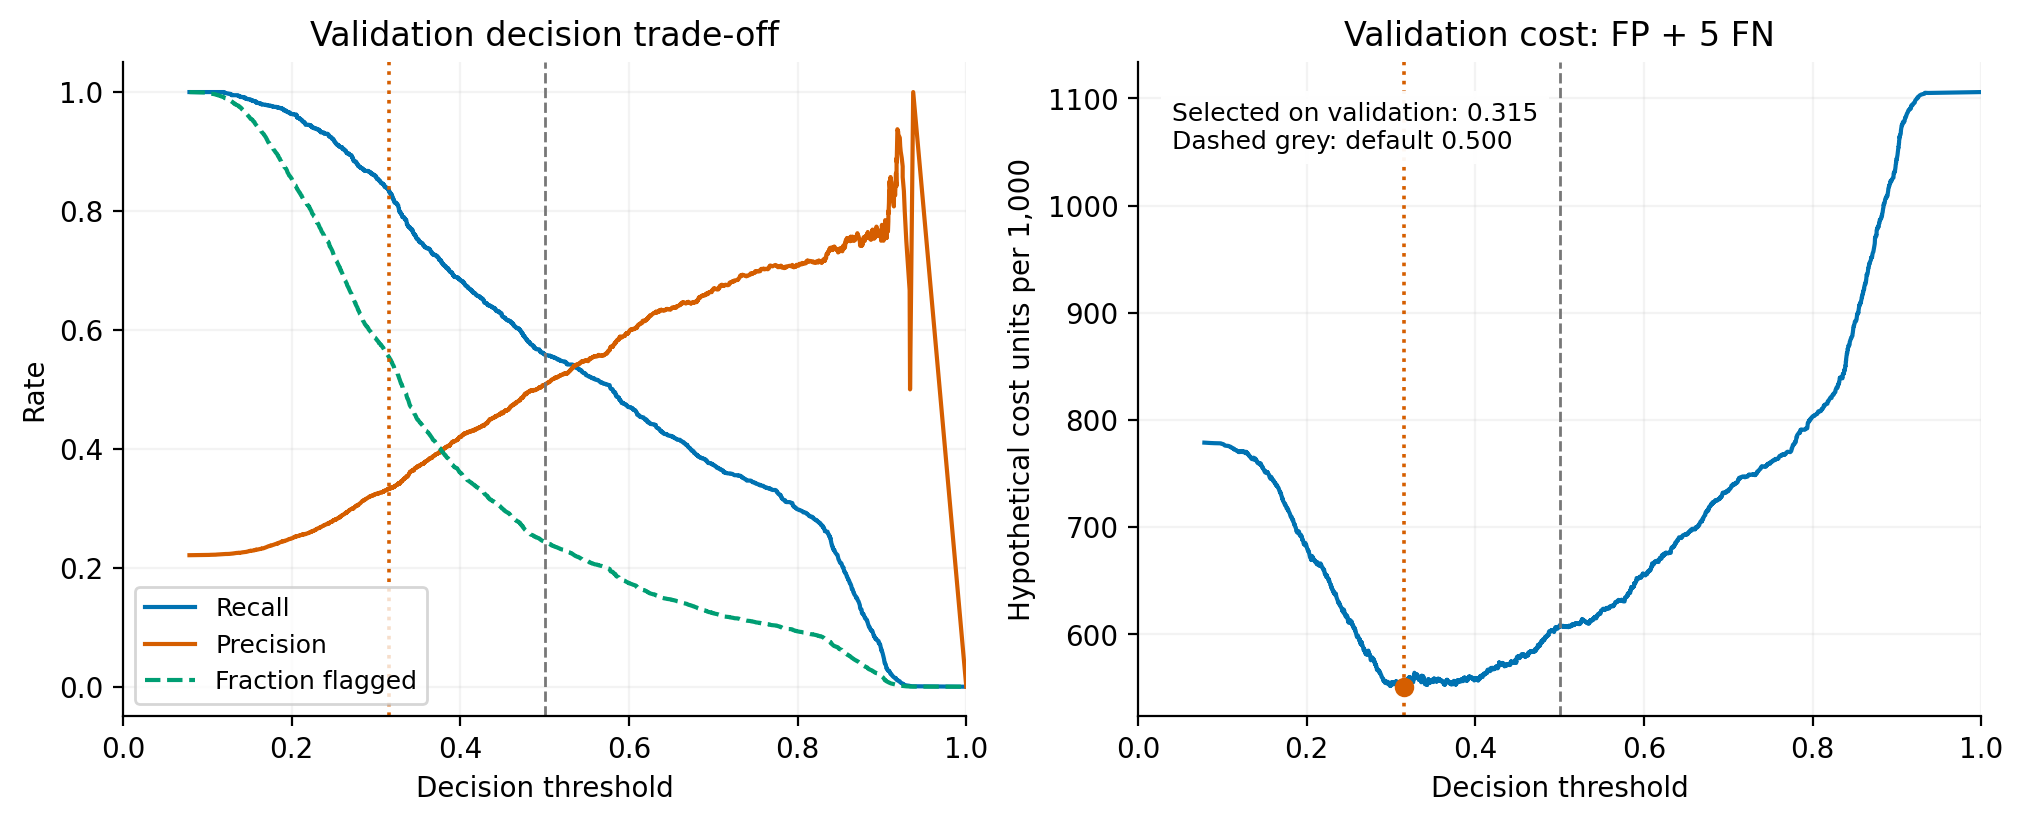

In [4]:
thresholds = protocol["Validation_thresholds"]
threshold_table = read_result("validation_thresholds.csv")
val_predictions = read_result("validation_predictions.csv")
val_metrics = read_result("validation_metrics.csv").set_index("Model")
for ratio, cutoff in thresholds.items():
    assert select_threshold(threshold_table, int(ratio)) == cutoff
    observed = metrics(val_predictions.default, val_predictions.Tuned_probability, cutoff)
    expected = val_metrics.loc[f"Tuned XGBoost / cost ratio {ratio}"]
    assert all(observed[k] == expected[k] for k in ["TN", "FP", "FN", "TP"])
display(pd.DataFrame({"FN:FP cost ratio": thresholds.keys(), "Validation-selected threshold": thresholds.values()}))
display(Image(filename=str(OUT / "figures/02_validation_threshold.png")))

## 4. Fixed test evaluation
The test set contains 1,327 defaults out of 6,000 observations (22.12%). Always predicting non-default therefore achieves 77.88% accuracy but misses every default.

Hyperparameter tuning did **not** improve test ranking: AP changed from 0.5544 to 0.5516, and ROC-AUC from 0.7773 to 0.7762. Changing the threshold does not change either ranking metric.

,Threshold,AP,ROC-AUC,Precision,Recall,Accuracy,FP,FN,Cost_5
Model,,,,,,,,,
Baseline XGBoost,0.5000,0.5544,0.7773,0.6565,0.3557,0.8163,247,855,4522
Tuned XGBoost,0.5000,0.5516,0.7762,0.5134,0.5486,0.7852,690,599,3685
Tuned XGBoost / cost ratio 1,0.7328,0.5516,0.7762,0.6652,0.3534,0.8177,236,858,4526
Tuned XGBoost / cost ratio 3,0.5345,0.5516,0.7762,0.5369,0.5260,0.7948,602,629,3747
Tuned XGBoost / cost ratio 5,0.3150,0.5516,0.7762,0.3276,0.8252,0.5867,2248,232,3408
Tuned XGBoost / cost ratio 10,0.2707,0.5516,0.7762,0.2939,0.8922,0.5020,2845,143,3560
Always negative,1.0000,0.2212,0.5000,0.0000,0.0000,0.7788,0,1327,6635
Always positive,0.0000,0.2212,0.5000,0.2212,1.0000,0.2212,4673,0,4673


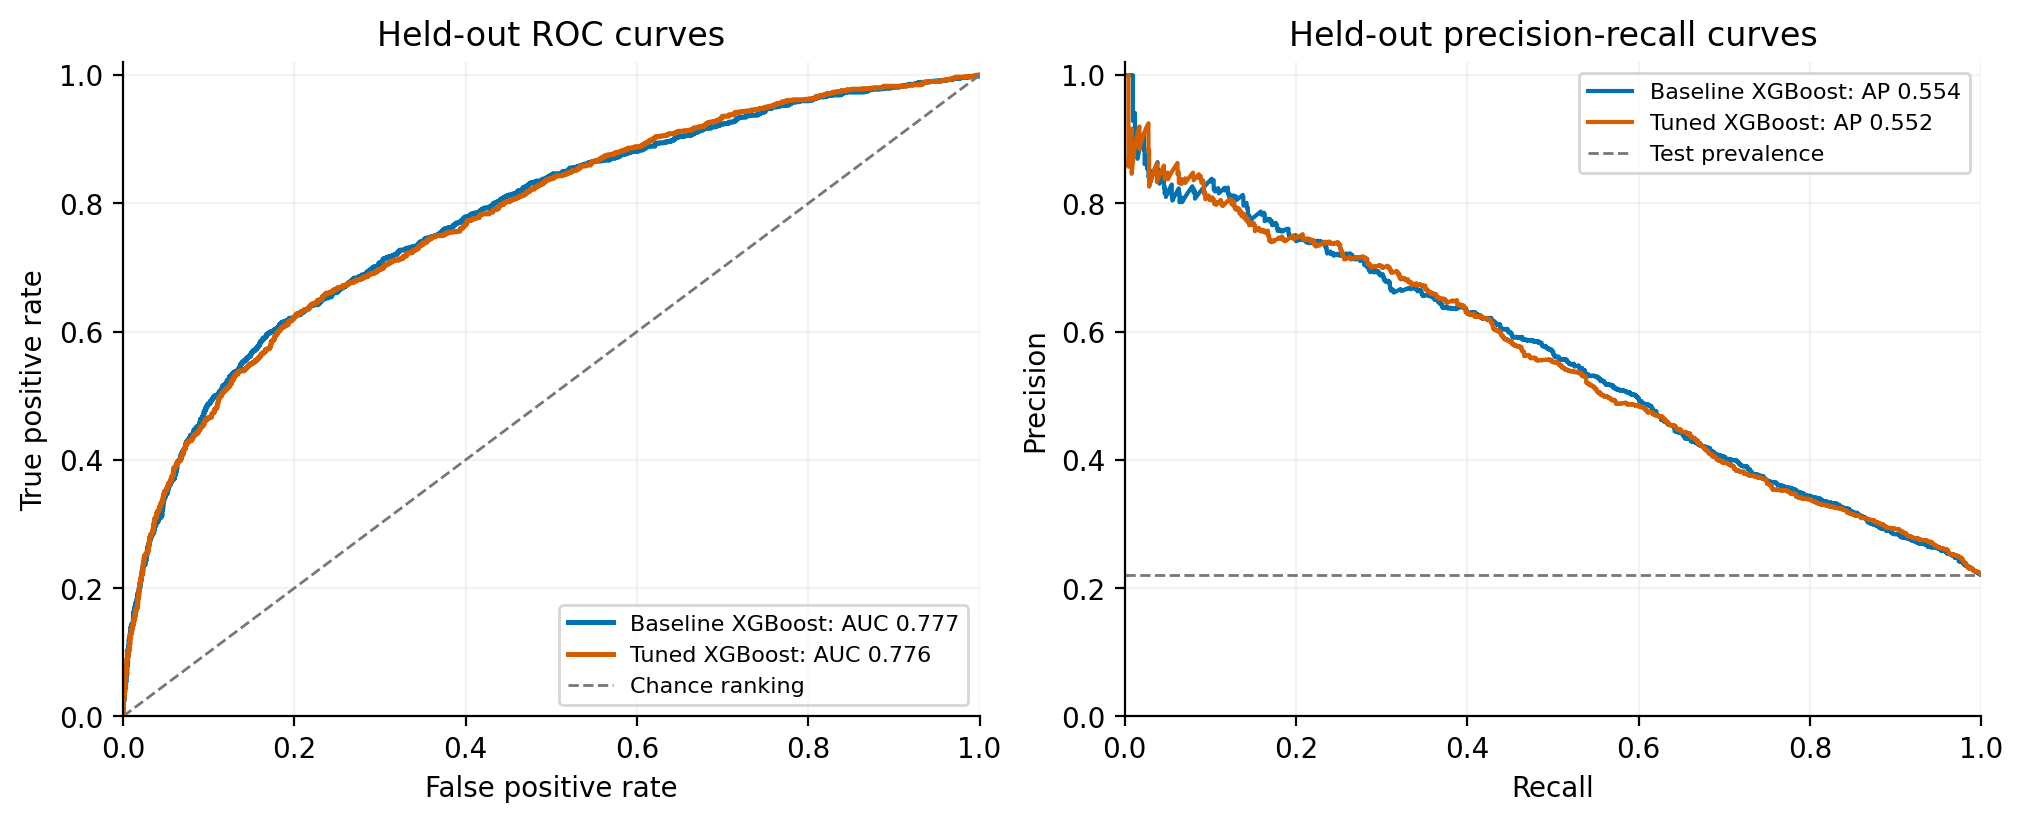

In [5]:
test = read_result("test_predictions.csv")
results = read_result("test_metrics.csv").set_index("Model")
assert len(test) == 6000 and set(test.row_id).isdisjoint(membership.row_id)
for name, row in results.iloc[:6].iterrows():
    column = "Baseline_probability" if name == "Baseline XGBoost" else "Tuned_probability"
    calculated = metrics(test.default, test[column], row.Threshold)
    for key, value in calculated.items():
        assert np.isclose(value, row[key]), (name, key)
display(results[["Threshold", "AP", "ROC-AUC", "Precision", "Recall", "Accuracy", "FP", "FN", "Cost_5"]].round(4))
display(Image(filename=str(OUT / "figures/01_ranking_curves.png")))

## 5. Cost and review burden
At the validation-selected cutoff of 0.3150, the **same tuned model** reduces missed defaults from 599 to 232, while false alarms increase from 690 to 2,248. Recall increases from 54.86% to 82.52%.

Under the assumed loss, 367 fewer missed defaults save $5\times367=1,835$ units, while 1,558 additional false alarms cost 1,558 units. The net saving is **277 units, or 7.52%**, compared with the tuned model at 0.5. However, the policy flags **55.72% of customers**, and accuracy falls to 58.67%. Whether that burden is acceptable needs actual costs and operational capacity.

,Primary scenario
Cost reduction (%),7.52
Additional defaults identified,367.00
Additional false positives,1558.00
Customers flagged (%),55.72


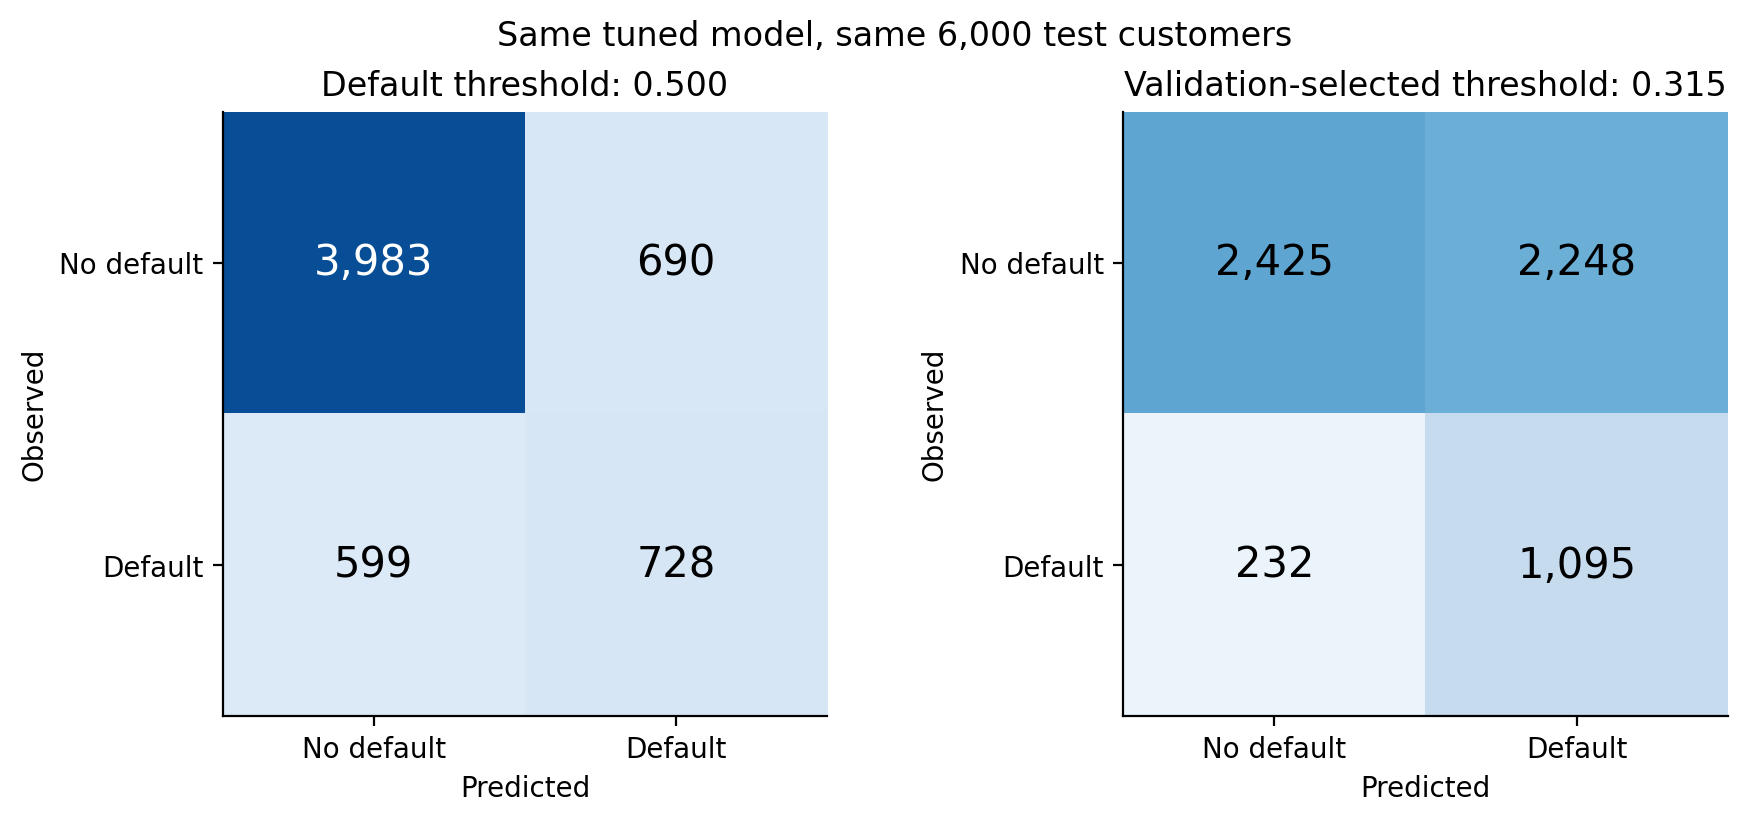

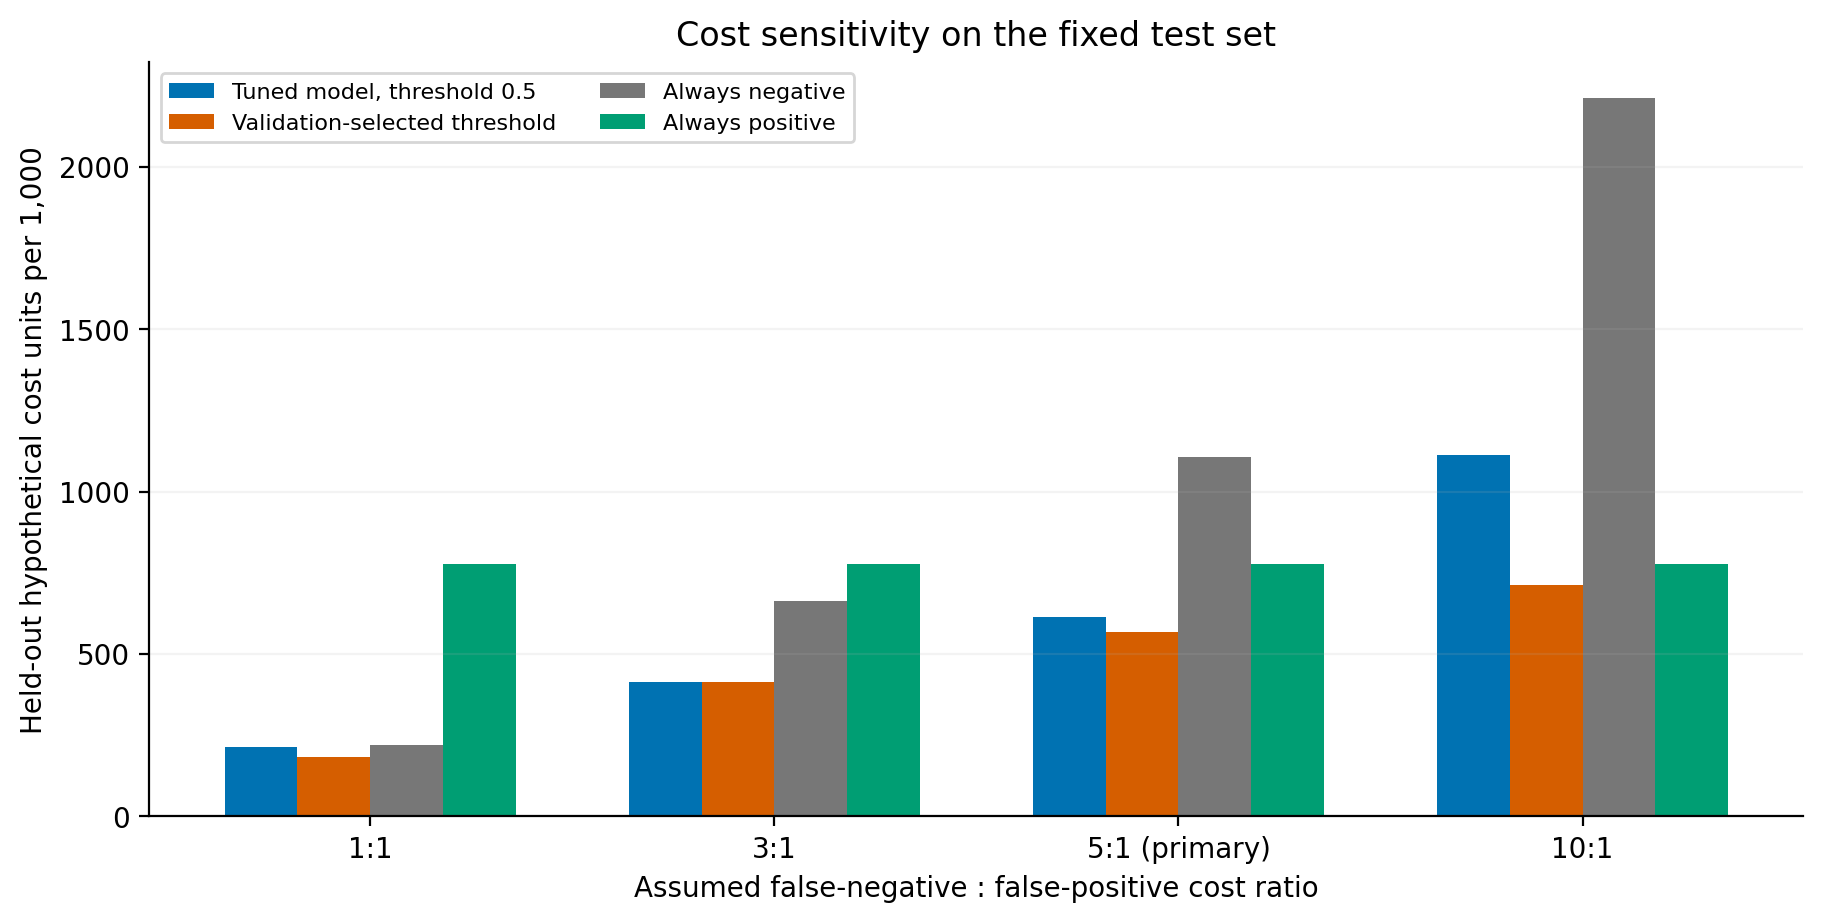

In [6]:
default = results.loc["Tuned XGBoost"]
selected = results.loc["Tuned XGBoost / cost ratio 5"]
display(pd.Series({
    "Cost reduction (%)": 100 * (default.Cost_5 - selected.Cost_5) / default.Cost_5,
    "Additional defaults identified": default.FN - selected.FN,
    "Additional false positives": selected.FP - default.FP,
    "Customers flagged (%)": 100 * selected.Alert_rate,
}, name="Primary scenario").to_frame().round(2))
display(Image(filename=str(OUT / "figures/03_confusion_matrices.png")))
display(Image(filename=str(OUT / "figures/05_cost_sensitivity.png")))

The sensitivity analysis is not uniformly favorable. At r=3, the validation-selected threshold has test cost 2,489 compared with 2,487 at threshold 0.5. Validation selection does not guarantee a better decision in every future sample.

## 6. Uncertainty and interpretation
The 1,000 stratified paired bootstrap replicates reuse the same sampled test rows for both methods. The AP and ROC-AUC difference intervals include zero. The primary cost difference interval is approximately **[-74.34, -18.00] units per 1,000 observations**. These intervals condition on the frozen models, thresholds and class counts; they exclude training and threshold-selection variability.

,Quantity,Estimate,CI_low,CI_high,Bootstrap_replicates
0,Tuned AP,0.55160,0.52713,0.57530,1000
1,Tuned ROC-AUC,0.77621,0.76144,0.79005,1000
2,AP difference: tuned - baseline,-0.00278,-0.01058,0.00536,1000
3,ROC-AUC difference: tuned - baseline,-0.00109,-0.00487,0.00283,1000
4,Cost/1000 difference: tuned r=5 threshold - tu...,-46.16667,-74.34167,-17.99583,1000


,Feature,Mean_AP_decrease,SD_AP_decrease
0,PAY_0,0.19894,0.00707
1,PAY_2,0.01211,0.00099
2,LIMIT_BAL,0.01178,0.00255
3,BILL_AMT1,0.00978,0.00427
4,PAY_3,0.00643,0.00275
5,PAY_AMT3,0.00427,0.00079
6,PAY_6,0.00406,0.00184
7,PAY_5,0.00402,0.00165
8,PAY_4,0.00392,0.00088
9,PAY_AMT2,0.00383,0.00087


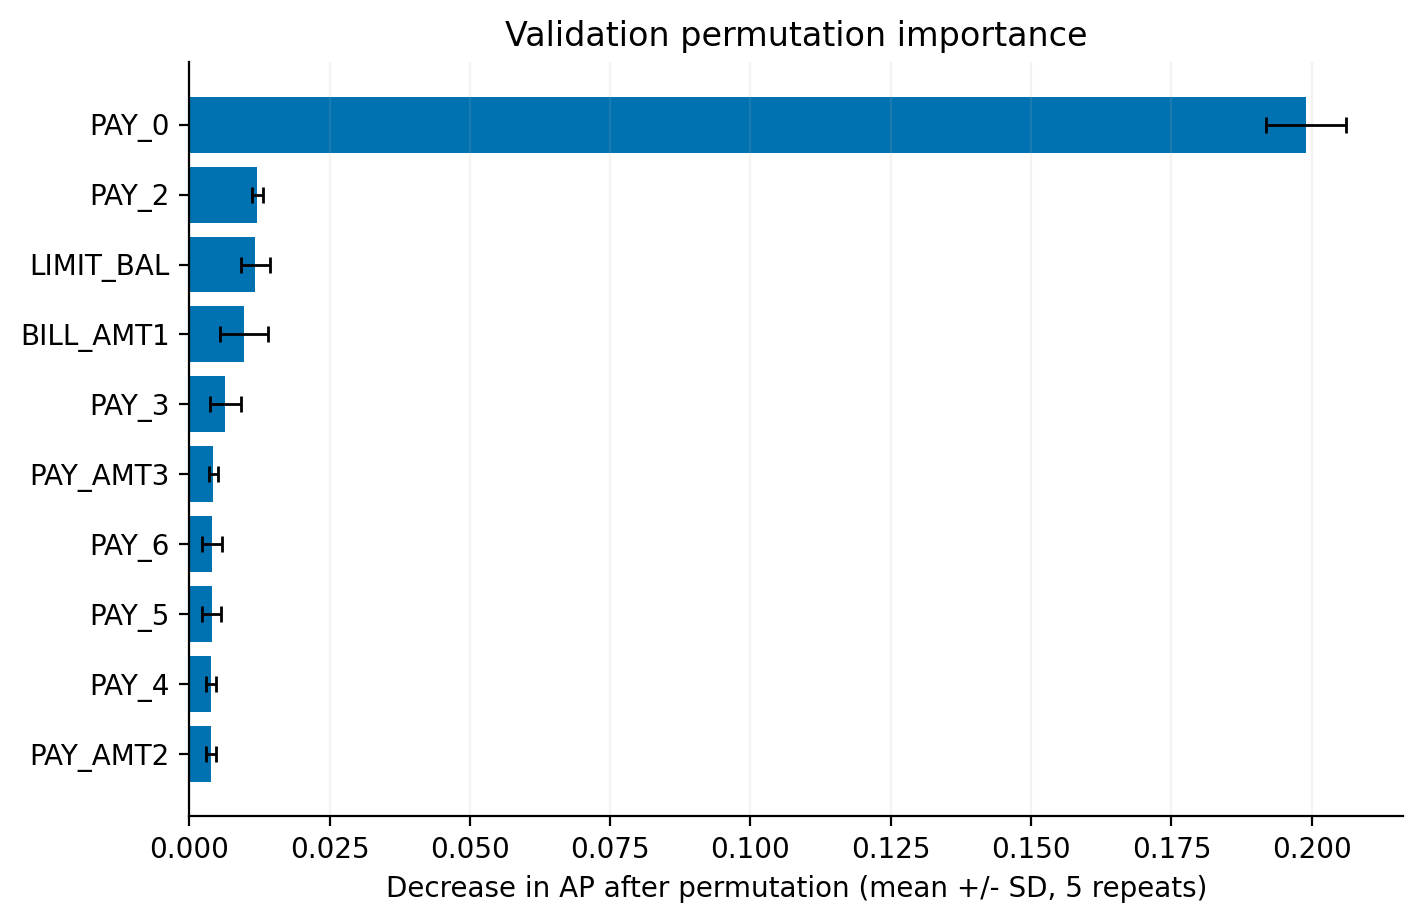

In [7]:
display(read_result("bootstrap_intervals.csv").round(5))
display(read_result("validation_importance.csv").head(10).round(5))
display(Image(filename=str(OUT / "figures/04_feature_importance.png")))

PAY_0 has the greatest validation permutation importance (AP decrease about 0.199), followed by PAY_2 and LIMIT_BAL. Importance measures predictive reliance, not causal effects; correlated predictors complicate individual attribution.

## 7. Limitations and conclusion
- Positive-class weighting changes scores. The tuned model is uncalibrated and its test Brier score is worse (0.1690 versus 0.1358). The cutoff 0.315 is **not** evidence of a calibrated 31.5% default probability.
- Historical Taiwanese records do not validate performance in a current banking population. The hypothetical loss omits loan exposure, recovery and customer effects.
- Fifteen test feature vectors also occur in development data. These were retained under the group protocol; identical feature values alone do not prove duplicate customers.
- Baseline and tuned XGBoost share the 18,000 fitting rows. Other members' fitting/validation allocations and PR metric definitions must be stated when combining results. No claim is made that XGBoost is the group's best model.

The supported finding is a decision-cost trade-off under a stated assumption, alongside **no clear ranking improvement from tuning**. Report both the reduced missed defaults and the increased false alarms.

## Sources and group handoff
- [UCI dataset](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients), DOI 10.24432/C55S3H.
- [XGBoost parameters](https://xgboost.readthedocs.io/en/stable/parameter.html).
- [Average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).
- [Decision threshold selection](https://scikit-learn.org/stable/modules/classification_threshold.html).
- [Permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html).

Use `docs/part4_report.md` for the English report section and `docs/part4_presentation.md` for the three-slide outline, talk and Q&A. The **combined group report**, including references, must fit within seven pages; the presentation including questions lasts 15 minutes.